# 3. Phân loại nhóm giá trị cầu thủ (Value-Tier Classification) & Phân cụm phong cách thi đấu mềm (GMM)

**Hướng A**: Phân loại cầu thủ vào các nhóm giá trị chuyển nhượng (Thấp / Trung bình / Cao / Ngôi sao), nhãn được tạo khách quan bằng phân vị (quantile) trên cột `value` có sẵn — không tự đặt ngưỡng chủ quan theo cảm tính bóng đá.

**Hướng C**: Mở rộng K-Means (notebook 2) sang Gaussian Mixture Model (GMM) — phân cụm mềm, cho ra xác suất thuộc mỗi nhóm phong cách thay vì gán cứng 1 nhãn.

## A.1 Đọc và làm sạch dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

def read_player_stats(path):
    """Đọc CSV theo từng dòng: thử UTF-8 trước, dòng nào lỗi (bị lưu bằng Latin-1)
    thì fallback sang Latin-1 cho đúng dòng đó. Tránh lỗi font kiểu 'JoÃ£o' do
    đọc toàn bộ file bằng encoding='latin-1' trước đây."""
    lines = []
    with open(path, 'rb') as f:
        for line in f:
            try:
                lines.append(line.decode('utf-8'))
            except UnicodeDecodeError:
                lines.append(line.decode('latin-1'))
    return pd.read_csv(StringIO(''.join(lines)))

df = read_player_stats('../data/player_stats.csv')
df = df.drop(columns=['marking'])

# Chuẩn hoá cột value về dạng số
df['value_numeric'] = df['value'].replace(r'[\$\.]', '', regex=True).astype(float)

print(f"Số cầu thủ: {df.shape[0]}")
df[['player', 'club', 'value', 'value_numeric']].head()

Số cầu thủ: 5682


,player,club,value,value_numeric
0,Cristian Castro Devenish,Atl. Nacional,$1.400.000,1400000.0
1,Silaldo Taffarel,Corinthians,$975.00,97500.0
2,Thomas Dähne,Holstein Kiel,$1.100.000,1100000.0
3,Michael Sollbauer,SK Rapid Wien,$650.00,65000.0
4,Diego Segovia,Independiente,$300.00,30000.0


## A.2 Tạo nhãn Value-Tier bằng phân vị (quantile)

Chia `value_numeric` thành 4 nhóm bằng nhau về số lượng cầu thủ (`pd.qcut`) — nhãn khách quan, xuất phát từ chính phân phối dữ liệu, không phải luật tự đặt.

In [2]:
labels = ['Thấp', 'Trung bình', 'Cao', 'Ngôi sao']
df['value_tier'] = pd.qcut(df['value_numeric'], q=4, labels=labels)

print(df['value_tier'].value_counts().reindex(labels))
print("\nNgưỡng giá trị (EUR) của từng nhóm:")
print(pd.qcut(df['value_numeric'], q=4).value_counts().sort_index())

value_tier
Thấp          1443
Trung bình    1441
Cao           1478
Ngôi sao      1320
Name: count, dtype: int64

Ngưỡng giá trị (EUR) của từng nhóm:
value_numeric
(399.999, 35000.0]          1443
(35000.0, 77500.0]          1441
(77500.0, 1600000.0]        1478
(1600000.0, 153500000.0]    1320
Name: count, dtype: int64


## A.3 Chọn đặc trưng (feature) và chia tập train/test

Dùng toàn bộ các chỉ số kỹ năng + thông tin thể chất (tuổi, chiều cao, cân nặng) làm đặc trưng. Không dùng `player`, `country`, `club` (định danh, không phải chỉ số năng lực) và tất nhiên không dùng `value`/`value_numeric` (vì đó là nguồn tạo ra nhãn — dùng lại sẽ gây rò rỉ dữ liệu/data leakage).

In [3]:
from sklearn.model_selection import train_test_split

exclude_cols = ['player', 'country', 'club', 'value', 'value_numeric', 'value_tier']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df['value_tier']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Số đặc trưng: {len(feature_cols)}")
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Số đặc trưng: 36
Train: 4545 | Test: 1137


## A.4 Huấn luyện Random Forest Classifier

Random Forest phù hợp vì: không cần chuẩn hóa dữ liệu, xử lý tốt số lượng lớn đặc trưng tương quan với nhau (nhiều chỉ số bóng đá vốn tương quan cao, VD sprint_speed và acceleration), và cho phép xem `feature_importances_` để diễn giải.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, target_names=labels))

Accuracy: 0.829

              precision    recall  f1-score   support

        Thấp       0.77      0.77      0.77       296
  Trung bình       0.84      0.88      0.86       264
         Cao       0.95      0.85      0.90       289
    Ngôi sao       0.77      0.81      0.79       288

    accuracy                           0.83      1137
   macro avg       0.83      0.83      0.83      1137
weighted avg       0.83      0.83      0.83      1137



## A.5 Ma trận nhầm lẫn (Confusion Matrix)

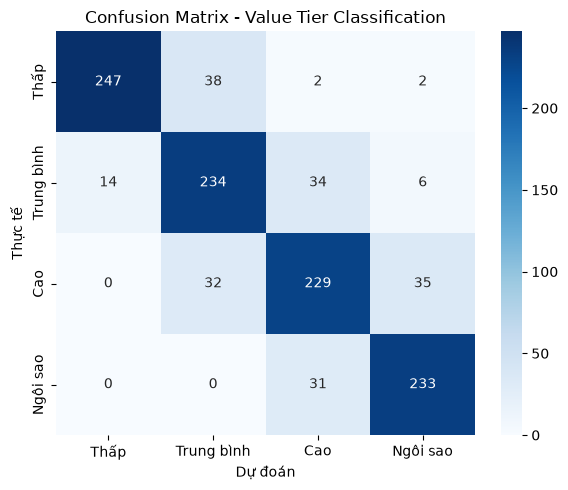

In [5]:
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix - Value Tier Classification')
plt.tight_layout()
plt.show()

## A.6 Feature Importance — chỉ số nào ảnh hưởng nhiều nhất đến giá trị cầu thủ

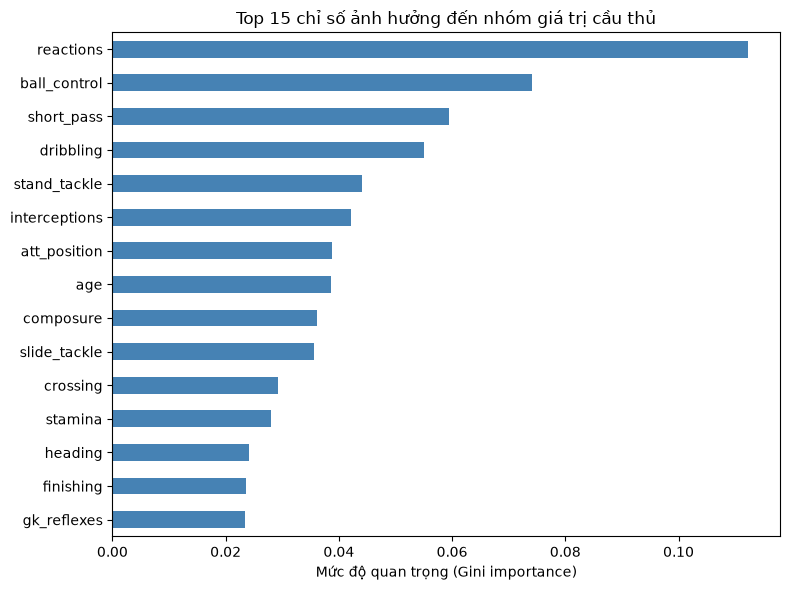

reactions        0.112307
ball_control     0.074068
short_pass       0.059443
dribbling        0.055057
stand_tackle     0.044081
interceptions    0.042132
att_position     0.038829
age              0.038563
composure        0.036053
slide_tackle     0.035675
dtype: float64

In [6]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 chỉ số ảnh hưởng đến nhóm giá trị cầu thủ')
plt.xlabel('Mức độ quan trọng (Gini importance)')
plt.tight_layout()
plt.show()

importances.head(10)

## A.7 Dự đoán xác suất theo từng nhóm (nếu muốn xem % thay vì chỉ nhãn cứng)

`predict_proba` vẫn dùng được ở đây một cách hợp lệ, vì lần này nhãn (`value_tier`) là nhãn thật (từ dữ liệu `value`), nên % trả về có ý nghĩa thống kê thực sự — khác với trường hợp vị trí (không có nhãn thật) đã bàn trước đó.

In [7]:
proba = clf.predict_proba(X_test)
proba_df = pd.DataFrame(proba, columns=clf.classes_, index=X_test.index)

sample = df.loc[X_test.index, ['player', 'club', 'value']].join(proba_df)
sample.sort_values('Ngôi sao', ascending=False).head(10)

,player,club,value,Cao,Ngôi sao,Thấp,Trung bình
329,Gerard Moreno,Villarreal CF,$53.000.000,0.000000,1.000000,0.0,0.0
175,Nikola Vlašić,Torino,$16.500.000,0.000000,1.000000,0.0,0.0
3851,João Cancelo,FC Bayern München,$72.000.000,0.000000,1.000000,0.0,0.0
2508,Moi Gómez,CA Osasuna,$14.000.000,0.000000,1.000000,0.0,0.0
5632,Oyarzabal,Real Sociedad,$40.500.000,0.000000,1.000000,0.0,0.0
5577,Harvey Barnes,Leicester City,$24.500.000,0.000000,1.000000,0.0,0.0
508,Yannick Carrasco,Atlético de Madrid,$42.500.000,0.000000,1.000000,0.0,0.0
5175,Hirving Lozano,Napoli FC,$28.000.000,0.000000,1.000000,0.0,0.0
3238,Cucurella,Chelsea,$27.000.000,0.000000,1.000000,0.0,0.0
567,Domenico Berardi,Sassuolo,$45.000.000,0.003333,0.996667,0.0,0.0


---
# C. Phân cụm phong cách thi đấu mềm (Gaussian Mixture Model)

Mở rộng notebook `2_kmeans_clustering.ipynb`: thay vì gán cứng 1 cụm/cầu thủ, GMM trả về **xác suất thuộc mỗi cụm** — phù hợp với việc một cầu thủ có thể mang đặc điểm pha trộn giữa nhiều phong cách.

In [8]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

style_features = ['sprint_speed', 'finishing', 'short_pass', 'slide_tackle', 'dribbling', 'strength']

df[style_features] = df[style_features].fillna(df[style_features].mean())
scaler = MinMaxScaler()
X_style = scaler.fit_transform(df[style_features])

## C.1 Chọn số cụm K bằng Silhouette Score

Thay vì chọn K=4 theo cảm tính ("chắc là 4 nhóm: tiền đạo/tiền vệ/hậu vệ/thủ môn"), thử nhiều giá trị K và chọn K có Silhouette Score cao nhất (đo mức độ tách biệt giữa các cụm) — quyết định dựa trên dữ liệu.

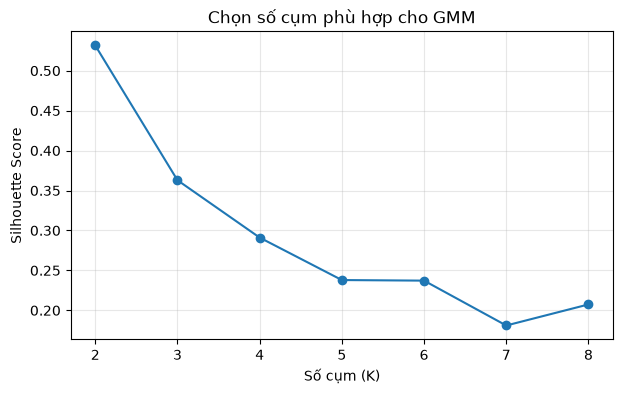

K tốt nhất theo Silhouette Score: 2 (score = 0.531)


In [9]:
scores = {}
for k in range(2, 9):
    gmm_k = GaussianMixture(n_components=k, random_state=42, n_init=5)
    cluster_labels = gmm_k.fit_predict(X_style)
    scores[k] = silhouette_score(X_style, cluster_labels)

plt.figure(figsize=(7, 4))
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.xlabel('Số cụm (K)')
plt.ylabel('Silhouette Score')
plt.title('Chọn số cụm phù hợp cho GMM')
plt.grid(alpha=0.3)
plt.show()

best_k = max(scores, key=scores.get)
print(f"K tốt nhất theo Silhouette Score: {best_k} (score = {scores[best_k]:.3f})")

## C.2 Huấn luyện GMM với K tốt nhất và lấy xác suất mềm

In [10]:
gmm = GaussianMixture(n_components=best_k, random_state=42, n_init=10)
gmm.fit(X_style)

df['gmm_cluster'] = gmm.predict(X_style)
cluster_proba = gmm.predict_proba(X_style)
cluster_proba_df = pd.DataFrame(
    cluster_proba,
    columns=[f'Cụm_{i}' for i in range(best_k)],
    index=df.index
)

df_gmm = pd.concat([df[['player', 'club'] + style_features + ['gmm_cluster']], cluster_proba_df], axis=1)

superstars = df_gmm[df_gmm['player'].str.contains('Ronaldo|Mbappé', na=False, case=False)]
superstars

,player,club,sprint_speed,finishing,short_pass,slide_tackle,dribbling,strength,gmm_cluster,Cụm_0,Cụm_1
2381,Ronaldo Damus,GIF Sundsvall,77,63,52,20,60,69,0,1.0,2.605160e-45
3401,Ronaldo Cabrais,Brazil,87,74,83,33,85,68,0,1.0,2.487951e-75
5229,Kylian Mbappé,Paris SG,97,93,85,32,93,76,0,1.0,2.047517e-112
5365,Ronaldo Vieira,Torino,76,53,72,68,71,71,0,1.0,2.345629e-81
5675,Kylian Mbappé,Paris SG,97,93,85,32,93,76,0,1.0,2.047517e-112
5680,Cristiano Ronaldo,Al Nassr,82,91,78,24,81,75,0,1.0,1.922421e-108


## C.3 Diễn giải các cụm (centroid trung bình mỗi cụm)

Xem trung bình từng chỉ số trong mỗi cụm để đặt tên phong cách phù hợp — vẫn cần diễn giải thủ công vì đây là unsupervised, nhưng ít nhất số cụm và ranh giới đã do dữ liệu quyết định, không phải đoán trước.

In [11]:
cluster_profile = df.groupby('gmm_cluster')[style_features].mean().round(1)
cluster_profile['số_lượng'] = df['gmm_cluster'].value_counts().sort_index()
cluster_profile

,sprint_speed,finishing,short_pass,slide_tackle,dribbling,strength,số_lượng
gmm_cluster,,,,,,,
0,68.5,50.8,63.3,50.8,61.5,66.1,5055
1,36.4,10.5,27.6,13.6,13.0,59.8,627


## C.4 Trực quan hóa (giữ nguyên góc nhìn Finishing vs Slide Tackle)

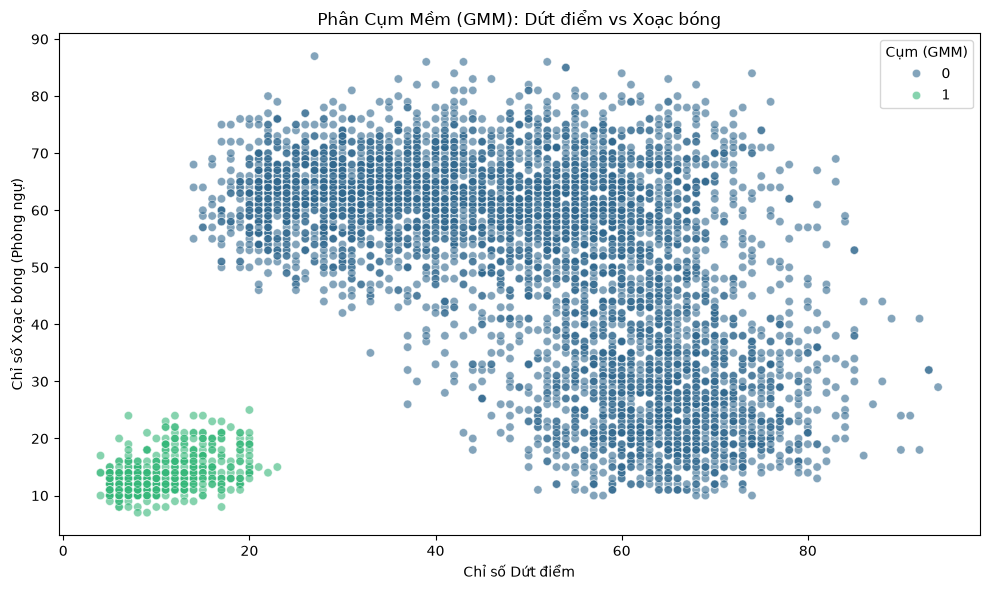

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='finishing',
    y='slide_tackle',
    hue='gmm_cluster',
    palette='viridis',
    alpha=0.6
)
plt.title('Phân Cụm Mềm (GMM): Dứt điểm vs Xoạc bóng')
plt.xlabel('Chỉ số Dứt điểm')
plt.ylabel('Chỉ số Xoạc bóng (Phòng ngự)')
plt.legend(title='Cụm (GMM)')
plt.tight_layout()
plt.show()

## C.5 Vì sao K=2 luôn thắng? — Kiểm tra cụm nhỏ là ai

Thử nhiều bộ đặc trưng khác nhau (rộng hơn, tập trung tấn công/phòng ngự...) đều cho ra cùng 1 kết quả: K=2 luôn có Silhouette Score cao nhất, và luôn tách ra một cụm nhỏ ~627 người. Kiểm tra thử xem cụm nhỏ này thực chất là ai.

In [13]:
small_cluster_id = df['gmm_cluster'].value_counts().idxmin()
small_cluster = df[df['gmm_cluster'] == small_cluster_id]

print(f"Cụm nhỏ có {len(small_cluster)} người")
print(f"gk_reflexes trung bình cụm nhỏ: {small_cluster['gk_reflexes'].mean():.1f}")
print(f"gk_reflexes trung bình phần còn lại: {df[df['gmm_cluster'] != small_cluster_id]['gk_reflexes'].mean():.1f}")
small_cluster[['player', 'gk_reflexes', 'finishing', 'dribbling']].head(5)

Cụm nhỏ có 627 người
gk_reflexes trung bình cụm nhỏ: 66.1
gk_reflexes trung bình phần còn lại: 10.4


,player,gk_reflexes,finishing,dribbling
2,Thomas Dähne,74,14,12
4,Diego Segovia,64,4,8
5,Cláudio Ramos,74,14,16
29,Andrew,74,4,10
34,Federico Lanzillotta,72,16,20


**Phát hiện**: cụm nhỏ chính là **thủ môn** (gk_reflexes trung bình ~66 so với ~10 ở phần còn lại) — dù `style_features` không hề dùng cột `gk_*` nào! Lý do: thủ môn có mọi chỉ số ngoài sân (dứt điểm, xoạc bóng, tốc độ chạy nước rút...) thấp đồng loạt, nên tự nhiên tách biệt rất rõ khỏi mọi cầu thủ khác — mạnh hơn hẳn bất kỳ khác biệt phong cách nào giữa các cầu thủ ngoài sân.

Đây là lý do GMM "chỉ tìm ra 2 nhóm" thay vì 4-6 nhóm theo phong cách như mong đợi: **thủ môn vs. ngoài sân là ranh giới mạnh nhất trong dữ liệu**, nó át hết các khác biệt phong cách tinh tế hơn (tiền đạo vs tiền vệ vs hậu vệ). Muốn thấy các phong cách trong nhóm cầu thủ ngoài sân, cần loại thủ môn ra trước.

## C.6 Phân cụm lại — chỉ trên cầu thủ ngoài sân (loại thủ môn)

Loại thủ môn bằng `gk_reflexes < 50` (ranh giới rất an toàn: thủ môn thật luôn ≥ 55, cầu thủ ngoài sân hiếm khi vượt quá 20), sau đó lặp lại quy trình chọn K bằng Silhouette Score với bộ đặc trưng rộng hơn, bao phủ đủ 3 khía cạnh: tấn công, chuyền/kiến tạo, phòng ngự.

Số cầu thủ ngoài sân: 5057 (đã loại 625 thủ môn)


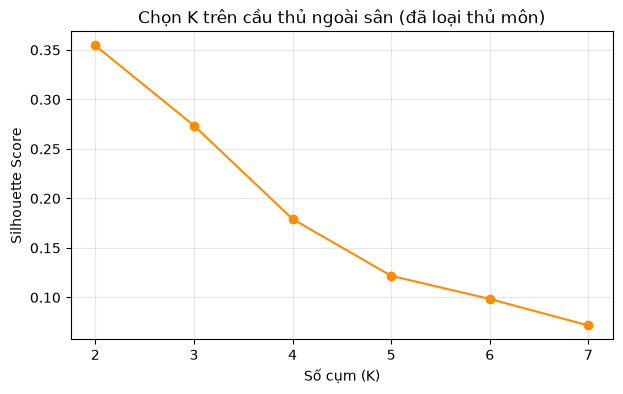

{2: 0.35449516488648075, 3: 0.2736612138043094, 4: 0.17918111590022592, 5: 0.12180476962463228, 6: 0.09841409521336161, 7: 0.07160810980204992}


In [14]:
outfield = df[df['gk_reflexes'] < 50].copy()
print(f"Số cầu thủ ngoài sân: {len(outfield)} (đã loại {len(df) - len(outfield)} thủ môn)")

style_features_v2 = ['finishing', 'long_shots', 'dribbling', 'crossing',
                      'short_pass', 'vision', 'slide_tackle', 'stand_tackle',
                      'interceptions', 'sprint_speed']

outfield[style_features_v2] = outfield[style_features_v2].fillna(outfield[style_features_v2].mean())
X_outfield = MinMaxScaler().fit_transform(outfield[style_features_v2])

scores_v2 = {}
for k in range(2, 8):
    gmm_k = GaussianMixture(n_components=k, random_state=42, n_init=5)
    cl = gmm_k.fit_predict(X_outfield)
    scores_v2[k] = silhouette_score(X_outfield, cl)

plt.figure(figsize=(7, 4))
plt.plot(list(scores_v2.keys()), list(scores_v2.values()), marker='o', color='darkorange')
plt.xlabel('Số cụm (K)')
plt.ylabel('Silhouette Score')
plt.title('Chọn K trên cầu thủ ngoài sân (đã loại thủ môn)')
plt.grid(alpha=0.3)
plt.show()
print(scores_v2)

Silhouette Score vẫn giảm dần theo K tăng (đặc điểm tự nhiên của dữ liệu phong cách bóng đá: ranh giới giữa các phong cách là **liên tục**, không rời rạc như GK/ngoài sân — một tiền vệ box-to-box nằm giữa tiền đạo và hậu vệ chứ không thuộc hẳn nhóm nào). Vì K=2 không đủ chi tiết để phân tích phong cách, chọn **K=3** làm điểm cân bằng: Silhouette vẫn ở mức chấp nhận được (~0.27, > 0.25 được xem là có cấu trúc cụm rõ ràng) và đủ chi tiết để diễn giải thành 3 nhóm phong cách có ý nghĩa bóng đá.

In [15]:
gmm_v2 = GaussianMixture(n_components=3, random_state=42, n_init=10)
outfield['style_cluster'] = gmm_v2.fit_predict(X_outfield)
style_proba = gmm_v2.predict_proba(X_outfield)
style_proba_df = pd.DataFrame(style_proba, columns=[f'%Nhóm_{i}' for i in range(3)], index=outfield.index)

cluster_profile_v2 = outfield.groupby('style_cluster')[style_features_v2].mean().round(1)
cluster_profile_v2['số_lượng'] = outfield['style_cluster'].value_counts().sort_index()
cluster_profile_v2

,finishing,long_shots,dribbling,crossing,short_pass,vision,slide_tackle,stand_tackle,interceptions,sprint_speed,số_lượng
style_cluster,,,,,,,,,,,
0,52.1,56.3,64.6,59.5,67.0,62.5,61.2,63.8,62.5,67.8,1743
1,64.1,60.2,67.2,55.7,63.1,60.8,31.0,33.5,31.9,72.7,1877
2,31.7,34.6,50.0,45.9,58.9,43.0,64.0,65.8,63.2,63.8,1437


Dựa trên centroid: Nhóm có `finishing`/`sprint_speed` cao + `interceptions` thấp → **Tấn công**; nhóm `interceptions`/`slide_tackle` cao + `finishing` thấp → **Phòng ngự**; nhóm còn lại (các chỉ số ở mức trung bình, cân bằng) → **Trung tuyến / Đa năng**. Xem ví dụ cầu thủ nổi tiếng theo từng nhóm để kiểm chứng trực quan:

In [16]:
cluster_names = {}
for c in sorted(outfield['style_cluster'].unique()):
    row = cluster_profile_v2.loc[c]
    if row['finishing'] > 55 and row['interceptions'] < 45:
        cluster_names[c] = 'Tấn công'
    elif row['interceptions'] > 55 and row['finishing'] < 45:
        cluster_names[c] = 'Phòng ngự'
    else:
        cluster_names[c] = 'Trung tuyến / Đa năng'

outfield['style_name'] = outfield['style_cluster'].map(cluster_names)
print(cluster_names)

sample_players = outfield[outfield['player'].str.contains(
    'Mbappé|Ronaldo|Ramos|Kanté|Modric|Van Dijk', na=False, case=False)]
sample_players[['player', 'style_name'] + style_features_v2].join(style_proba_df)

{np.int64(0): 'Trung tuyến / Đa năng', np.int64(1): 'Tấn công', np.int64(2): 'Phòng ngự'}


,player,style_name,finishing,long_shots,dribbling,crossing,short_pass,vision,slide_tackle,stand_tackle,interceptions,sprint_speed,%Nhóm_0,%Nhóm_1,%Nhóm_2
2164,Hector Gairamos,Trung tuyến / Đa năng,40,42,61,61,68,56,52,52,58,77,7.738831e-01,1.990593e-02,2.062110e-01
2381,Ronaldo Damus,Tấn công,63,54,60,35,52,44,20,17,15,77,7.972761e-14,1.000000e+00,1.237680e-22
2850,Gonçalo Ramos,Tấn công,80,67,73,60,71,63,21,42,34,77,3.089492e-13,1.000000e+00,8.404814e-30
3138,Sergio Ramos,Trung tuyến / Đa năng,65,64,63,63,78,71,83,82,84,55,9.176104e-01,3.381104e-04,8.205150e-02
3401,Ronaldo Cabrais,Tấn công,74,78,85,83,83,83,33,35,40,87,3.814466e-15,1.000000e+00,1.120822e-17
3413,Juan Manuel Ramos,Phòng ngự,53,43,68,64,60,53,67,61,71,73,7.744477e-02,9.783962e-02,8.247156e-01
3660,Diegildo Ramos,Tấn công,74,81,70,62,68,66,20,28,12,32,3.512930e-18,1.000000e+00,3.204839e-25
4211,Virgil van Dijk,Phòng ngự,52,64,70,53,79,65,86,91,89,89,2.870734e-02,2.749076e-07,9.712924e-01
5229,Kylian Mbappé,Tấn công,93,82,93,78,85,83,32,34,38,97,1.720482e-16,1.000000e+00,1.109397e-23
5365,Ronaldo Vieira,Trung tuyến / Đa năng,53,62,71,56,72,66,68,71,68,76,9.942818e-01,8.334214e-05,5.634865e-03


**Lưu ý minh bạch cho báo cáo**: việc đặt tên "Tấn công / Phòng ngự / Trung tuyến" ở đây vẫn là diễn giải thủ công dựa trên centroid — bản thân GMM không biết khái niệm bóng đá, nó chỉ tìm ra 3 vùng mật độ dữ liệu khác nhau. Điều được đảm bảo bằng dữ liệu là: **số cụm (K=3)** và **ranh giới giữa các cụm** (xác suất mềm), không phải **tên gọi** của cụm. Đây là cách trình bày trung thực, tránh bị đánh giá là "gán nhãn theo cảm tính" như lo ngại ban đầu của đề tài.

---
## Tổng kết

- **Hướng A** cho ra một bài toán classification hợp lệ với nhãn khách quan (`value_tier` từ quantile), có accuracy/F1 đáng tin cậy, và `predict_proba` cho % có ý nghĩa thống kê thật.
- **Hướng C** nâng cấp từ K-Means sang GMM: chọn K bằng Silhouette Score thay vì đoán. Phát hiện quan trọng: ranh giới mạnh nhất trong dữ liệu là **thủ môn vs. ngoài sân** (K=2 luôn thắng vì lý do này, không phải vì chỉ có 2 phong cách). Sau khi loại thủ môn, phân cụm lại trên cầu thủ ngoài sân cho ra 3 nhóm phong cách diễn giải được (Tấn công / Phòng ngự / Trung tuyến) với xác suất mềm theo từng cụm — nhưng tên gọi cụm vẫn là diễn giải thủ công dựa trên centroid, không phải nhãn được kiểm chứng.